In [78]:
!pip install langid -q

In [79]:
from datasets import load_dataset
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

token = UserSecretsClient().get_secret("hf_token")
login(token=token) 
pc = load_dataset("issai/kazsandra", "polarity_classification")


# Preprocessing different langs + merging

## Kazakh dataset load + cleaning

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(pc['train'])
print(df.head())
print(df.columns.tolist())
print(df.dtypes)

      custom_id                                     text  \
0  pla015439pla                               Өтте күшті   
1  pla083193pla  Мәбазар жок .Оте керемет тамаша керемет   
2  pla113624pla             Кушти , дал тура айтады 👍👍👍👍   
3  pla029825pla                              Реклама коп   
4  pla002604pla                           5-баға беремін   

                             text_cleaned  label    domain  
0                              өтте күшті      1  appstore  
1  мәбазар жок оте керемет тамаша керемет      1  appstore  
2                   кушти дал тура айтады      1  appstore  
3                             реклама коп      0  appstore  
4                          5 баға беремін      1  appstore  
['custom_id', 'text', 'text_cleaned', 'label', 'domain']
custom_id       object
text            object
text_cleaned    object
label            int64
domain          object
dtype: object


In [81]:
df

,custom_id,text,text_cleaned,label,domain
0,pla015439pla,Өтте күшті,өтте күшті,1,appstore
1,pla083193pla,Мәбазар жок .Оте керемет тамаша керемет,мәбазар жок оте керемет тамаша керемет,1,appstore
2,pla113624pla,"Кушти , дал тура айтады 👍👍👍👍",кушти дал тура айтады,1,appstore
3,pla029825pla,Реклама коп,реклама коп,0,appstore
4,pla002604pla,5-баға беремін,5 баға беремін,1,appstore
...,...,...,...,...,...
134363,pla052260pla,ҰБТ тапсырғандар барма қиию 2005 тер 140/140 ж...,ұбт тапсырғандар барма қиию 2005 тер 140 140 ж...,1,appstore
134364,pla080146pla,Орнатуы акырын🤯😡,орнатуы акырын,0,appstore
134365,kas022701kas,Уақытынан ерте келді рахмет!,уақытынан ерте келді рахмет,1,market
134366,pla104320pla,Бұл ең жақсы кейзіт екен,бұл ең жақсы кейзіт екен,1,appstore


label
1    110417
0     23951
Name: count, dtype: int64


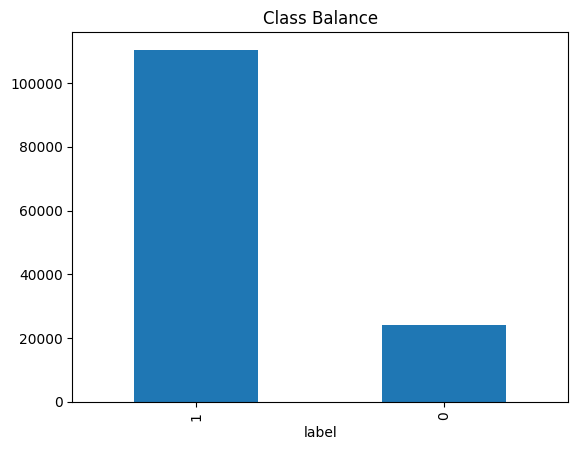

In [82]:
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar', title='Class Balance')
plt.show()

            text_len     word_count
count  134368.000000  134368.000000
mean       59.823187       8.612050
std        67.002375       9.192461
min         2.000000       1.000000
25%        24.000000       4.000000
50%        40.000000       6.000000
75%        69.000000      10.000000
max      1939.000000     268.000000


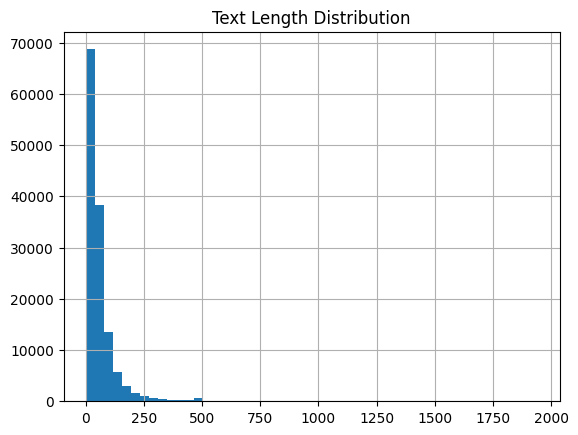

In [83]:
df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
print(df[['text_len', 'word_count']].describe())
df['text_len'].hist(bins=50)
plt.title('Text Length Distribution')
plt.show()

In [84]:
print(df[['text_len', 'word_count']].describe())

print(df['text_len'].quantile([0.90, 0.95, 0.99]))
print(df['word_count'].quantile([0.90, 0.95, 0.99]))

            text_len     word_count
count  134368.000000  134368.000000
mean       59.823187       8.612050
std        67.002375       9.192461
min         2.000000       1.000000
25%        24.000000       4.000000
50%        40.000000       6.000000
75%        69.000000      10.000000
max      1939.000000     268.000000
0.90    121.00
0.95    173.00
0.99    370.33
Name: text_len, dtype: float64
0.90    17.0
0.95    24.0
0.99    50.0
Name: word_count, dtype: float64


In [85]:
# Cleaning too long reviews in kz 
df = df[(df['word_count'] >= 3) & (df['text_len'] <= 400)]

print(f"Left: {len(df)} from 134368 ({len(df)/134368*100:.1f}%)")
print(df[['text_len', 'word_count']].describe())

Left: 119314 from 134368 (88.8%)
            text_len     word_count
count  119314.000000  119314.000000
mean       60.969149       8.832660
std        52.878343       7.190195
min         6.000000       3.000000
25%        28.000000       4.000000
50%        43.000000       6.000000
75%        73.000000      11.000000
max       400.000000     112.000000


In [86]:
df['lang_label'] = 'kk'

/tmp/ipykernel_57/67566274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lang_label'] = 'kk'


### Undersampling

In [87]:
kk_neg = df[(df['lang_label'] == 'kk') & (df['label'] == 0)]  # ~23K
kk_pos = df[(df['lang_label'] == 'kk') & (df['label'] == 1)].sample(n=len(kk_neg), random_state=42)
kk_balanced = pd.concat([kk_neg, kk_pos])  # ~46K итого

kk_balanced["label"].value_counts()

label
0    20412
1    20412
Name: count, dtype: int64

## Russian dataset loading + cleaning

In [88]:
rus_df = pd.read_csv("/kaggle/input/datasets/mar1mba/russian-sentiment-dataset/sentiment_dataset.csv")
rus_df

,text,label,src
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews
4,Мне не очень понравилось это платье. Размер ...,0,rureviews
...,...,...,...
290453,Как всегда вкусный и свежий.,1,perekrestok
290454,Обалденный!,1,perekrestok
290455,"Достоинства:\nВкусно, лучшая паста\n\nНедостат...",1,perekrestok
290456,"Достоинства:\nУвлажняет очень хорошо, и кожа к...",1,perekrestok


In [89]:
#basic preproc
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

russian_stopwords = set(stopwords.words('russian'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^а-яёa-z\s]', '', text)  
    tokens = text.split()
    tokens = [w for w in tokens if w not in russian_stopwords]
    return ' '.join(tokens) 

rus_df['text_clean'] = rus_df['text'].apply(clean_text)

print(rus_df[['text', 'text_clean']].head(3))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0  Пальто красивое, но пришло с дырой в молнии. П...   
1  Очень долго шел заказ,ждала к новому году,приш...   
2  Могу сказать одно, брюки нормальные, НО они бы...   

                                          text_clean  
0  пальто красивое пришло дырой молнии просила вы...  
1  очень долго шел заказждала новому годупришел н...  
2  могу сказать одно брюки нормальные порваны мал...  


In [90]:
rus_df

,text,label,src,text_clean
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews,пальто красивое пришло дырой молнии просила вы...
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews,очень долго шел заказждала новому годупришел н...
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews,могу сказать одно брюки нормальные порваны мал...
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews,доставка быстрая меньше месяца заказывали разм...
4,Мне не очень понравилось это платье. Размер ...,0,rureviews,очень понравилось это платье размер l подошёл ...
...,...,...,...,...
290453,Как всегда вкусный и свежий.,1,perekrestok,вкусный свежий
290454,Обалденный!,1,perekrestok,обалденный
290455,"Достоинства:\nВкусно, лучшая паста\n\nНедостат...",1,perekrestok,достоинства вкусно лучшая паста недостатки дор...
290456,"Достоинства:\nУвлажняет очень хорошо, и кожа к...",1,perekrestok,достоинства увлажняет очень кожа светлеет стои...


In [91]:

rus_df = rus_df[rus_df['label'] != 0].copy()  # get rid of Neutral (0)
rus_df['label'] = rus_df['label'].map({1: 1, 2: 0})  # Positive→1, Negative→0
print(rus_df['label'].value_counts())

label
0    96992
1    96877
Name: count, dtype: int64


### Undersampling

In [92]:
print(rus_df['label'].value_counts())
print(len(rus_df))

label
0    96992
1    96877
Name: count, dtype: int64
193869


In [93]:
ru_neg = rus_df[rus_df['label'] == 0].sample(n=len(kk_neg), random_state=42)
ru_pos = rus_df[rus_df['label'] == 1].sample(n=len(kk_neg), random_state=42)
ru_balanced = pd.concat([ru_neg, ru_pos])  # ~46K итого
print(ru_balanced['label'].value_counts())

label
0    20412
1    20412
Name: count, dtype: int64


## Merging datasets

In [99]:
# kk
kk_final = kk_balanced[['text_cleaned', 'label', 'lang_label']].copy()
kk_final = kk_final.rename(columns={'text_cleaned': 'text'})

# ru
ru_final = ru_balanced[['text_clean', 'label']].copy()
ru_final = ru_final.rename(columns={'text_clean': 'text'})
ru_final['lang_label'] = 'ru'

# merge
merged_df = pd.concat([kk_final, ru_final], ignore_index=True)
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(merged_df.columns.tolist())
print(merged_df['lang_label'].value_counts())
print(merged_df['label'].value_counts())
merged_df.head()

['text', 'label', 'lang_label']
lang_label
ru    40824
kk    40824
Name: count, dtype: int64
label
1    40824
0    40824
Name: count, dtype: int64


,text,label,lang_label
0,году специальную экономическую зону морпорт ак...,1,ru
1,мынау жақсы екен орнатыңыздар,1,kk
2,посмотрела сорок восемь серий двадцать восьмой...,1,ru
3,гадость гадкая,0,ru
4,обычно всё устраивает это пельмени ломаные вар...,0,ru


In [100]:
#save to csv
merged_df.to_csv('merged_dataset.csv', index=False, encoding='utf-8-sig')
print(f"Saved: {len(merged_df)} lines")
print(merged_df.columns.tolist())

Saved: 81648 lines
['text', 'label', 'lang_label']
